Homework 4: Iterative Methods

In [14]:
#imports 
import numpy as np
import matplotlib.pyplot as plt 

Jacobi Method

In [20]:
import numpy as np
def jacobi(A, b, x0, tol, max_iterations):
    tracked_errors = []
    n = len(b)
    x = x0.copy()
    for k in range(max_iterations):
        x_new = np.zeros_like(x)
        for i in range(n):
            s = sum(A[i][j] * x[j] for j in range(n) if j != i)
            x_new[i] = (b[i] - s) / A[i][i]
        
        # Check for convergence
        tracked_errors.append(np.linalg.norm(x_new - x, ord=np.inf))
        if np.linalg.norm(x_new - x, ord=np.inf) < tol:
            return x_new, k, tracked_errors 
    
        x = x_new
    return x, max_iterations, tracked_errors


In [21]:
import numpy as np
import timeit
import time

def gauss_seidel(A, b, x0, tol, max_iterations):
    tracked_errors = []
    n = len(b)
    x = x0.copy()
    
    for k in range(max_iterations):
        x_new = x.copy()
        
        for i in range(n):
            s1 = sum(A[i][j] * x_new[j] for j in range(i)) # Using already updated values
            s2 = sum(A[i][j] * x[j] for j in range(i + 1, n)) # Using old values
            x_new[i] = (b[i] - s1 - s2) / A[i][i]
            
        # Check for convergence
        tracked_errors.append(np.linalg.norm(x_new - x, ord=np.inf))
        if np.linalg.norm(x_new - x, ord=np.inf) < tol:
            return x_new, k,tracked_errors 
            
        x = x_new

    return x, max_iterations, tracked_errors


In [8]:
# Plot graph with the highest precision 10^-9

Gauss Sidel Method Results: 0.001
iterations:  3
solution:  [ 3.00000035 -2.50000004  6.99999999]

Gauss Sidel Method Results: 1e-06
iterations:  4
solution:  [ 3.  -2.5  7. ]

Gauss Sidel Method Results: 1e-09
iterations:  6
solution:  [ 3.  -2.5  7. ]

method: Jacobi - tol: 0.001
iterations:  3
solution:  [ 3.0000225  -2.50000266  6.99998104]

method: Jacobi - tol: 1e-06
iterations:  6
solution:  [ 3.  -2.5  7. ]

method: Jacobi - tol: 1e-09
iterations:  8
solution:  [ 3.  -2.5  7. ]



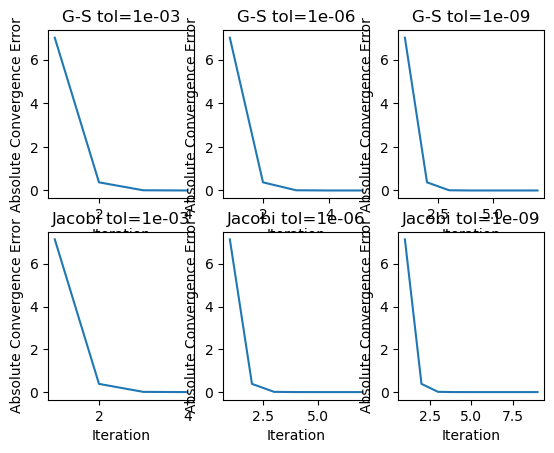

In [36]:
A = np.array([[3,-.1,-.2],
              [.1,7,-.3],
              [.3,-.2,10]])
b = np.array([7.85,-19.3,71.4])
x0 = np.zeros_like(b)
max_iterations = 100
tolerances = np.array([1e-3,1e-6,1e-9]) 

for i in range (tolerances.size):
    print("Gauss Sidel Method Results:", tolerances[i])
    plt.subplot(2,3,i+1)

    solution, iterations, error = gauss_seidel(A, b, x0, tolerances[i], max_iterations)
    print("iterations: ", iterations)
    print("solution: ", solution)
    print()
    
    x=np.arange(1,len(error)+1)
    plt.plot(x, error)
    plt.title(f"G-S tol={tolerances[i]:.0e}") 
    plt.xlabel("Iteration")
    plt.ylabel("Absolute Convergence Error")

    
#repeating the same  flow but for jacobi in the seconf row
for i in range(tolerances.size):
    print("method: Jacobi - tol:", tolerances[i])
    plt.subplot(2,3,i+4)
    
    solution, iterations, error = jacobi(A, b, x0, tolerances[i], max_iterations)
    print("iterations: ", iterations)
    print("solution: ", solution)
    print()
    
    x=np.arange(1,len(error)+1)
    plt.plot(x, error)
    plt.title(f"Jacobi tol={tolerances[i]:.0e}") 
    plt.xlabel("Iteration")
    plt.ylabel("Absolute Convergence Error")


